In [1]:
!pip install transformers torch scikit-learn seaborn --quiet

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn.functional as F
from transformers import (
    BertTokenizer,
    BertModel,
    BertForMaskedLM,
    pipeline,
    logging as hf_logging,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

hf_logging.set_verbosity_error()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   PyTorch  : {torch.__version__}")
print(f"   Device   : {device.upper()} {'a' if device=='cuda' else ' (switch to GPU for speed)'}")

   PyTorch  : 2.10.0+cpu
   Device   : CPU  (switch to GPU for speed)


In [4]:
MODEL_NAME = "bert-base-uncased"

print("[1/2] Loading tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print("[2/2] Loading BERT MLM model (downloads ~440 MB on first run)...")
mlm_model = BertForMaskedLM.from_pretrained(MODEL_NAME, output_attentions=True)
mlm_model.eval()
mlm_model.to(device)

print(f"\nBERT loaded successfully!")
print(f"   Vocab size       : {tokenizer.vocab_size:,}")
print(f"   Parameters       : {sum(p.numel() for p in mlm_model.parameters()):,}")
print(f"   Hidden layers    : {mlm_model.config.num_hidden_layers}")
print(f"   Attention heads  : {mlm_model.config.num_attention_heads}")
print(f"   Hidden size      : {mlm_model.config.hidden_size}")


[1/2] Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[2/2] Loading BERT MLM model (downloads ~440 MB on first run)...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


BERT loaded successfully!
   Vocab size       : 30,522
   Parameters       : 109,514,298
   Hidden layers    : 12
   Attention heads  : 12
   Hidden size      : 768


In [6]:
mlm_pipe = pipeline("fill-mask", model=MODEL_NAME, device=0 if device=="cuda" else -1)

sentences = [
    "The [MASK] is the powerhouse of the cell.",
    "Paris is the [MASK] of France.",
    "Machine learning is a subset of [MASK] intelligence.",
    "She studied hard and [MASK] the exam with flying colours.",
    "The [MASK] barked loudly in the middle of the night.",
]

mlm_records = []
print("=" * 60)
for sent in sentences:
    preds = mlm_pipe(sent)
    top3 = [(p["token_str"], round(p["score"], 4)) for p in preds[:3]]
    mlm_records.append({
        "Masked Sentence": sent,
        "Top Prediction": top3[0][0],
        "Confidence": top3[0][1],
        "Top-3 Predictions": str(top3),
    })
    print(f"{sent}")
    for rank, (tok, score) in enumerate(top3, 1):
        print(f"   #{rank} '{tok}'  ({score:.4f})")
    print()

mlm_df = pd.DataFrame(mlm_records)
print("\n MLM Summary Table:")
print(mlm_df[["Masked Sentence", "Top Prediction", "Confidence"]].to_string(index=False))


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

The [MASK] is the powerhouse of the cell.
   #1 'female'  (0.0193)
   #2 'woman'  (0.0143)
   #3 'speaker'  (0.0110)

Paris is the [MASK] of France.
   #1 'capital'  (0.9969)
   #2 'heart'  (0.0006)
   #3 'center'  (0.0004)

Machine learning is a subset of [MASK] intelligence.
   #1 'artificial'  (0.9881)
   #2 'machine'  (0.0056)
   #3 'natural'  (0.0016)

She studied hard and [MASK] the exam with flying colours.
   #1 'passed'  (0.9350)
   #2 'took'  (0.0168)
   #3 'topped'  (0.0119)

The [MASK] barked loudly in the middle of the night.
   #1 'dog'  (0.4974)
   #2 'dogs'  (0.3280)
   #3 'cat'  (0.0157)


 MLM Summary Table:
                                          Masked Sentence Top Prediction  Confidence
                The [MASK] is the powerhouse of the cell.         female      0.0193
                           Paris is the [MASK] of France.        capital      0.9969
     Machine learning is a subset of [MASK] intelligence.     artificial      0.9881
She studied hard and [MASK

In [7]:
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if device=="cuda" else -1,
)

test_texts = [
    "I absolutely love how BERT understands the context of words!",
    "The model's performance was disappointing and below expectations.",
    "Natural language processing is a fascinating and rapidly growing field.",
    "I'm not sure if I like this approach — it feels overly complicated.",
    "The results were neither great nor terrible, just average.",
    "LangChain makes integrating LLMs into applications surprisingly easy.",
    "This was a complete waste of time and effort.",
    "The breakthrough paper introduced a revolutionary new architecture.",
]

sent_records = []
print("=" * 70)
for text in test_texts:
    out = sentiment_pipe(text)[0]
    label = out["label"]
    score = round(out["score"], 4)
    icon  = "true" if label == "POSITIVE" else "false"
    sent_records.append({"Text": text, "Sentiment": label, "Score": score})
    print(f"{icon} [{label:<8}] {score:.4f}  |  {text[:65]}")

sent_df = pd.DataFrame(sent_records)
print(f"\n {(sent_df.Sentiment=='POSITIVE').sum()} POSITIVE  |  {(sent_df.Sentiment=='NEGATIVE').sum()} NEGATIVE")


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

true [POSITIVE] 0.9999  |  I absolutely love how BERT understands the context of words!
false [NEGATIVE] 0.9990  |  The model's performance was disappointing and below expectations.
true [POSITIVE] 0.9998  |  Natural language processing is a fascinating and rapidly growing 
false [NEGATIVE] 0.9996  |  I'm not sure if I like this approach — it feels overly complicate
false [NEGATIVE] 0.9873  |  The results were neither great nor terrible, just average.
true [POSITIVE] 0.9950  |  LangChain makes integrating LLMs into applications surprisingly e
false [NEGATIVE] 0.9998  |  This was a complete waste of time and effort.
true [POSITIVE] 0.9997  |  The breakthrough paper introduced a revolutionary new architectur

 4 POSITIVE  |  4 NEGATIVE


In [8]:
embed_model = BertModel.from_pretrained(MODEL_NAME)
embed_model.eval()
embed_model.to(device)

def get_cls_embedding(text):
    tokens = tokenizer(text, return_tensors="pt",
                       truncation=True, max_length=128, padding=True)
    tokens = {k: v.to(device) for k, v in tokens.items()}
    with torch.no_grad():
        out = embed_model(**tokens)
    return out.last_hidden_state[:, 0, :].cpu().numpy()

sentences_sim = [
    "The cat sat on the mat.",               # S1
    "A feline rested on the rug.",            # S2  ← similar to S1
    "Dogs love to play fetch in the park.",   # S3
    "Machine learning requires large data.",  # S4
    "Deep learning is a subfield of AI.",     # S5  ← similar to S4
    "The weather today is sunny and warm.",   # S6  ← isolated
]

print("Computing BERT embeddings...")
embeddings = np.vstack([get_cls_embedding(s) for s in sentences_sim])
sim_matrix = cosine_similarity(embeddings)

sim_df = pd.DataFrame(
    sim_matrix.round(3),
    index=[f"S{i+1}" for i in range(len(sentences_sim))],
    columns=[f"S{i+1}" for i in range(len(sentences_sim))],
)

print("\nSentence Reference:")
for i, s in enumerate(sentences_sim):
    print(f"  S{i+1}: {s}")
print("\nCosine Similarity Matrix:")
print(sim_df.to_string())


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing BERT embeddings...

Sentence Reference:
  S1: The cat sat on the mat.
  S2: A feline rested on the rug.
  S3: Dogs love to play fetch in the park.
  S4: Machine learning requires large data.
  S5: Deep learning is a subfield of AI.
  S6: The weather today is sunny and warm.

Cosine Similarity Matrix:
       S1     S2     S3     S4     S5     S6
S1  1.000  0.936  0.836  0.813  0.791  0.830
S2  0.936  1.000  0.811  0.778  0.776  0.799
S3  0.836  0.811  1.000  0.778  0.710  0.845
S4  0.813  0.778  0.778  1.000  0.883  0.796
S5  0.791  0.776  0.710  0.883  1.000  0.752
S6  0.830  0.799  0.845  0.796  0.752  1.000


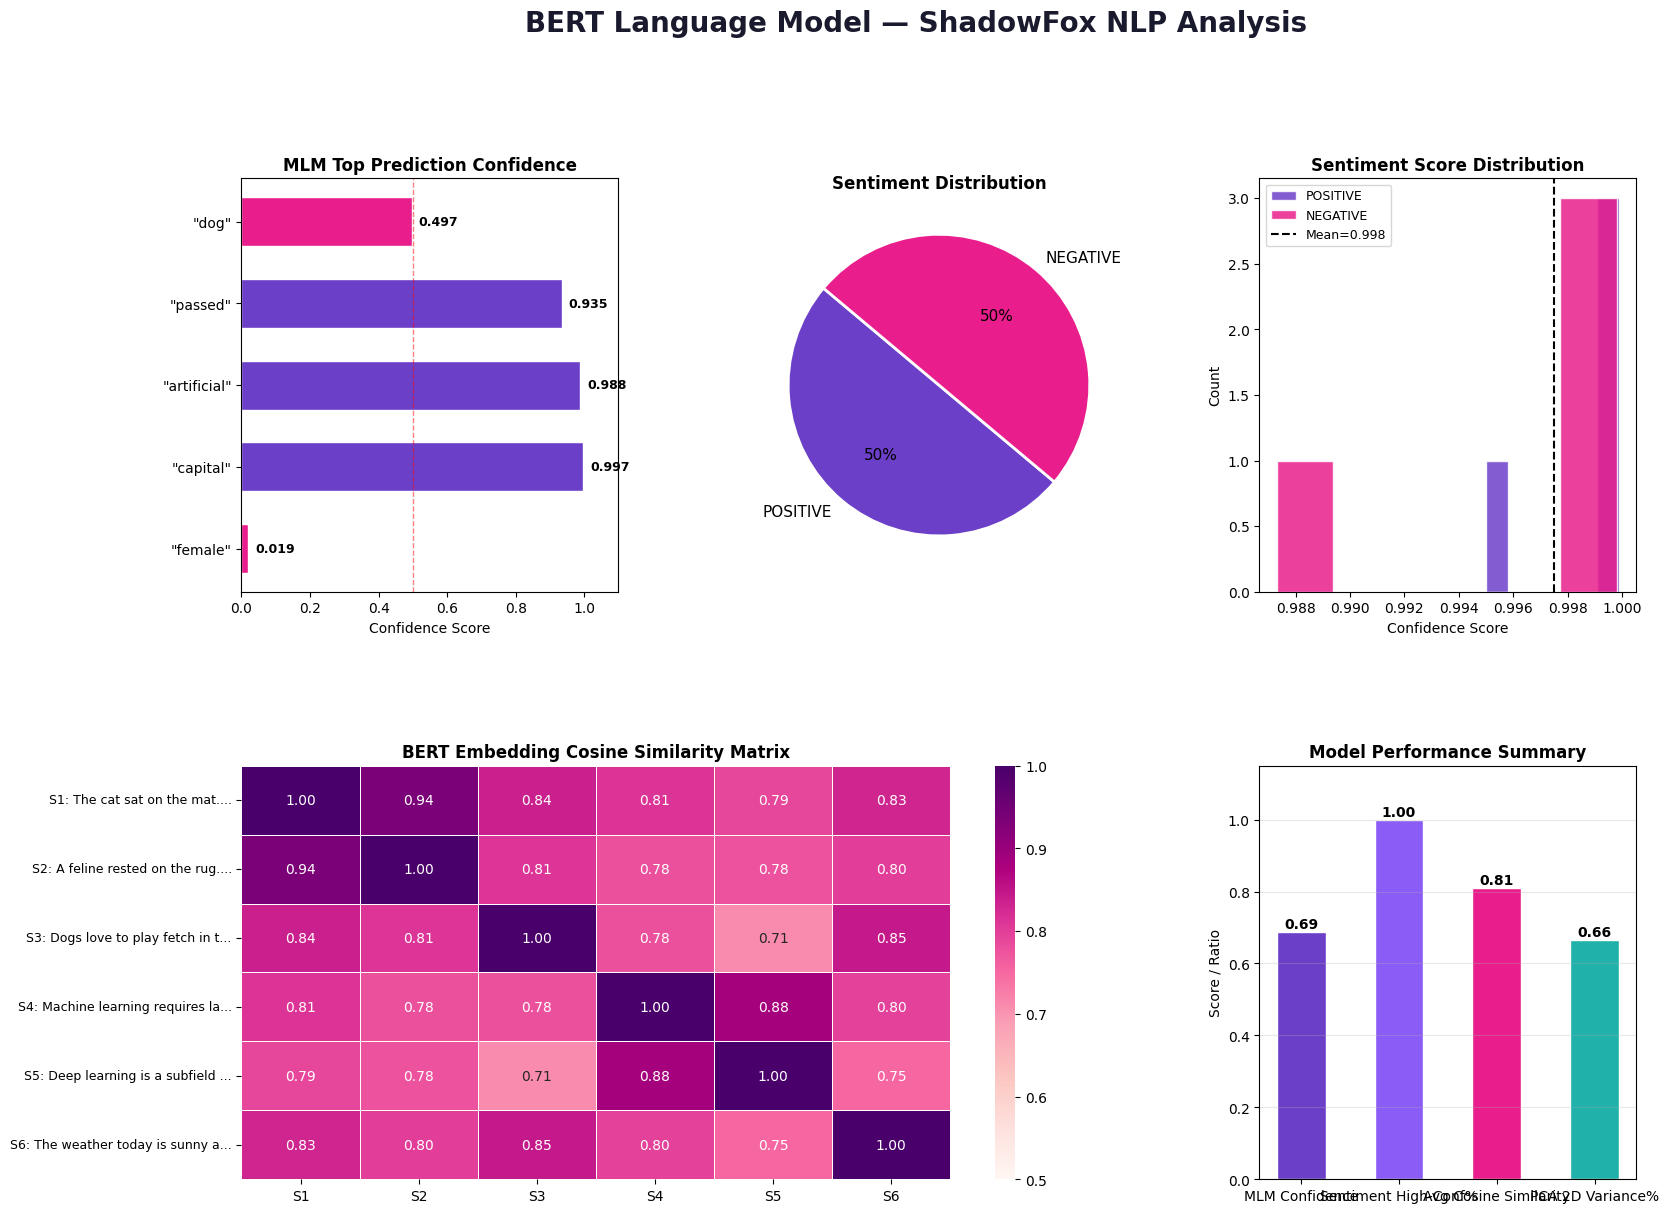

In [11]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle("BERT Language Model — ShadowFox NLP Analysis", fontsize=20,
             fontweight="bold", y=1.01, color="#1a1a2e")

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)


ax1 = fig.add_subplot(gs[0, 0])
palette = ["#6C3FC8" if c > 0.6 else "#E91E8C" for c in mlm_df["Confidence"]]
bars = ax1.barh(range(len(mlm_df)), mlm_df["Confidence"], color=palette, edgecolor="white", height=0.6)
ax1.set_yticks(range(len(mlm_df)))
ax1.set_yticklabels([f'"{r["Top Prediction"]}"' for _, r in mlm_df.iterrows()], fontsize=10)
ax1.set_xlabel("Confidence Score", fontsize=10)
ax1.set_title("MLM Top Prediction Confidence", fontsize=12, fontweight="bold")
ax1.set_xlim(0, 1.1)
ax1.axvline(0.5, color="red", linestyle="--", alpha=0.5, linewidth=1)
for bar, val in zip(bars, mlm_df["Confidence"]):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9, fontweight="bold")


ax2 = fig.add_subplot(gs[0, 1])
pos = (sent_df["Sentiment"] == "POSITIVE").sum()
neg = (sent_df["Sentiment"] == "NEGATIVE").sum()
wedges, texts, autos = ax2.pie(
    [pos, neg], labels=["POSITIVE", "NEGATIVE"],
    autopct="%1.0f%%", colors=["#6C3FC8", "#E91E8C"],
    startangle=140, textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax2.set_title("Sentiment Distribution", fontsize=12, fontweight="bold")


ax3 = fig.add_subplot(gs[0, 2])
pos_scores = sent_df[sent_df["Sentiment"] == "POSITIVE"]["Score"]
neg_scores = sent_df[sent_df["Sentiment"] == "NEGATIVE"]["Score"]
ax3.hist(pos_scores, bins=6, color="#6C3FC8", alpha=0.85, label="POSITIVE", edgecolor="white")
ax3.hist(neg_scores, bins=6, color="#E91E8C", alpha=0.85, label="NEGATIVE", edgecolor="white")
ax3.axvline(sent_df["Score"].mean(), color="black", linestyle="--",
            linewidth=1.5, label=f'Mean={sent_df["Score"].mean():.3f}')
ax3.set_xlabel("Confidence Score", fontsize=10)
ax3.set_ylabel("Count", fontsize=10)
ax3.set_title("Sentiment Score Distribution", fontsize=12, fontweight="bold")
ax3.legend(fontsize=9)

ax4 = fig.add_subplot(gs[1, 0:2])
labels_sim = [f"S{i+1}: {s[:28]}..." for i, s in enumerate(sentences_sim)]
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="RdPu",
            xticklabels=[f"S{i+1}" for i in range(len(sentences_sim))],
            yticklabels=labels_sim,
            ax=ax4, linewidths=0.5, vmin=0.5, vmax=1.0,
            annot_kws={"size": 10})
ax4.set_title("BERT Embedding Cosine Similarity Matrix", fontsize=12, fontweight="bold")
ax4.tick_params(axis="y", labelsize=9)


ax5 = fig.add_subplot(gs[1, 2])
pca_temp = PCA(n_components=2, random_state=42)
pca_temp.fit(embeddings)
perf_vals  = [mlm_df["Confidence"].mean(),
              (sent_df["Score"] > 0.85).mean(),
              sim_matrix[~np.eye(len(sim_matrix), dtype=bool)].mean(),
              sum(pca_temp.explained_variance_ratio_)]
perf_labels = ["MLM Confidence", "Sentiment High-Conf%", "Avg Cosine Similarity", "PCA 2D Variance%"]
bar_colors  = ["#6C3FC8", "#8B5CF6", "#E91E8C", "#20B2AA"]
bars5 = ax5.bar(perf_labels, perf_vals, color=bar_colors, edgecolor="white", width=0.5)
for bar, val in zip(bars5, perf_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
ax5.set_ylim(0, 1.15)
ax5.set_ylabel("Score / Ratio", fontsize=10)
ax5.set_title("Model Performance Summary", fontsize=12, fontweight="bold")
ax5.grid(axis="y", alpha=0.3)
plt.show()